In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
raw_path = Path("../data/raw")
list(raw_path.glob("*"))

[WindowsPath('../data/raw/.gitkeep'),
 WindowsPath('../data/raw/acn_caltech_sessions_2019_2021.json'),
 WindowsPath('../data/raw/acn_data.csv')]

In [3]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

#preliminary inspection of dataset
df.head()
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16127 entries, 0 to 16126
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               16127 non-null  str    
 1   userinputs        13894 non-null  str    
 2   sessionid         16127 non-null  str    
 3   stationid         16127 non-null  str    
 4   spaceid           16127 non-null  str    
 5   siteid            16127 non-null  int64  
 6   clusterid         16127 non-null  int64  
 7   connectiontime    16127 non-null  str    
 8   disconnecttime    16127 non-null  str    
 9   kwhdelivered      16127 non-null  float64
 10  donechargingtime  14080 non-null  str    
 11  timezone          16127 non-null  str    
 12  userid            13894 non-null  float64
dtypes: float64(2), int64(2), str(9)
memory usage: 1.6 MB


In [4]:
#check for null values
df.isnull().sum().sort_values(ascending=False)

print(df["_id"].head())
print(df["timezone"].head())

0    5c3fda9df9af8b0d99c6fd60
1    5c3fda9df9af8b0d99c6fd61
2    5c412c1df9af8b12cb56c27c
3    5c412c1df9af8b12cb56c27d
4    5c412c1df9af8b12cb56c27e
Name: _id, dtype: str
0    America/Los_Angeles
1    America/Los_Angeles
2    America/Los_Angeles
3    America/Los_Angeles
4    America/Los_Angeles
Name: timezone, dtype: str


In [15]:
#convert to ensure datatype is datetime
df["connectiontime"] = pd.to_datetime(df["connectiontime"], errors="coerce")
df["disconnecttime"] = pd.to_datetime(df["disconnecttime"], errors="coerce")
df["donechargingtime"] = pd.to_datetime(df["donechargingtime"], errors="coerce")

#create duration of charge at station
df["duration_hours"] = (
    df["disconnecttime"] - df["connectiontime"]
).dt.total_seconds() / 3600

#splits dataset into different columns for EDA
df["hour"] = df["connectiontime"].dt.hour
df["day_of_week"] = df["connectiontime"].dt.dayofweek
df["month"] = df["connectiontime"].dt.month
df["date"] = df["connectiontime"].dt.date

#converts hours to sin and cos making hour 23 and hour 0 closer in value
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

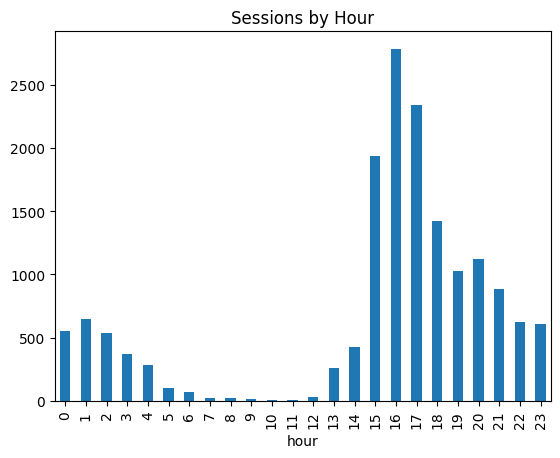

In [16]:
df.groupby("hour").size().plot(kind="bar", title="Sessions by Hour")
plt.show()

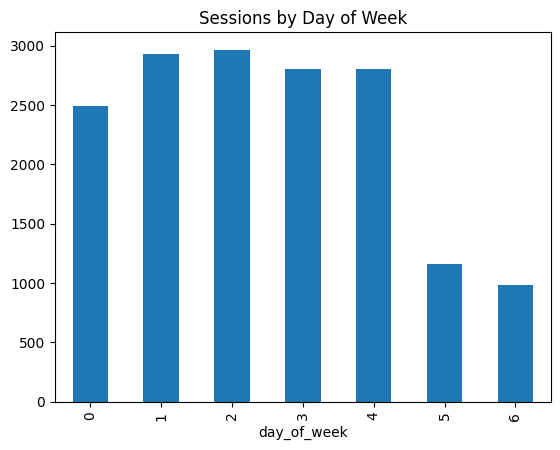

In [17]:
df.groupby("day_of_week").size().plot(kind="bar", title="Sessions by Day of Week")
plt.show()

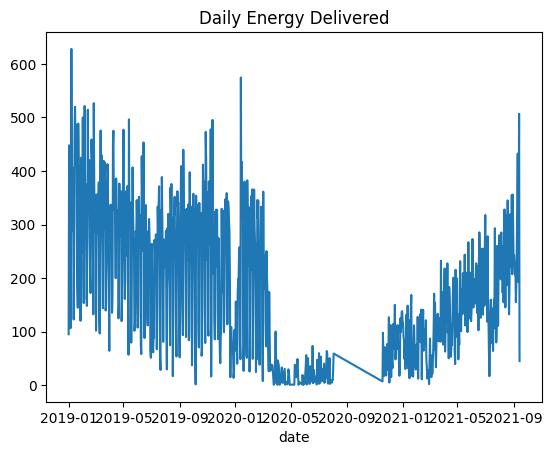

In [18]:
df.groupby("date")["kwhdelivered"].sum().plot(title="Daily Energy Delivered")
plt.show()

In [19]:
daily = (
    df.groupby("date")
      .agg(
          daily_energy=("kwhdelivered", "sum"),
          session_count=("sessionid", "count"),
          avg_duration=("duration_hours", "mean"),
          avg_hour_sin=("hour_sin", "mean"),
          avg_hour_cos=("hour_cos", "mean")
      )
      .reset_index()
)

daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values("date")
daily.head()

,date,daily_energy,session_count,avg_duration,avg_hour_sin,avg_hour_cos
0,2019-01-01,95.166,10,3.991028,-0.488014,0.395327
1,2019-01-02,447.890,29,7.439818,-0.865761,-0.148639
2,2019-01-03,325.439,34,6.577345,-0.662459,0.125517
3,2019-01-04,322.516,31,7.478369,-0.735195,-0.026024
4,2019-01-05,106.364,13,3.243291,-0.641303,-0.034484


In [20]:
daily["day_of_week"] = daily["date"].dt.dayofweek
daily["month"] = daily["date"].dt.month
daily["day_of_month"] = daily["date"].dt.day
daily["week_of_year"] = daily["date"].dt.isocalendar().week.astype(int)
daily["is_weekend"] = daily["day_of_week"].isin([5, 6]).astype(int)

daily_model = daily.dropna().copy()

In [21]:
split_idx = int(len(daily_model) * 0.8)
train = daily_model.iloc[:split_idx]
test = daily_model.iloc[split_idx:]

feature_cols = ["day_of_week", "month", "day_of_month", "week_of_year", "is_weekend","avg_hour_sin","avg_hour_cos"]
X_train = train[feature_cols]
y_train = train["daily_energy"]
X_test = test[feature_cols]
y_test = test["daily_energy"]

Linear Regression MAE: 68.2704070356896
Linear Regression RMSE: 86.34029508020616


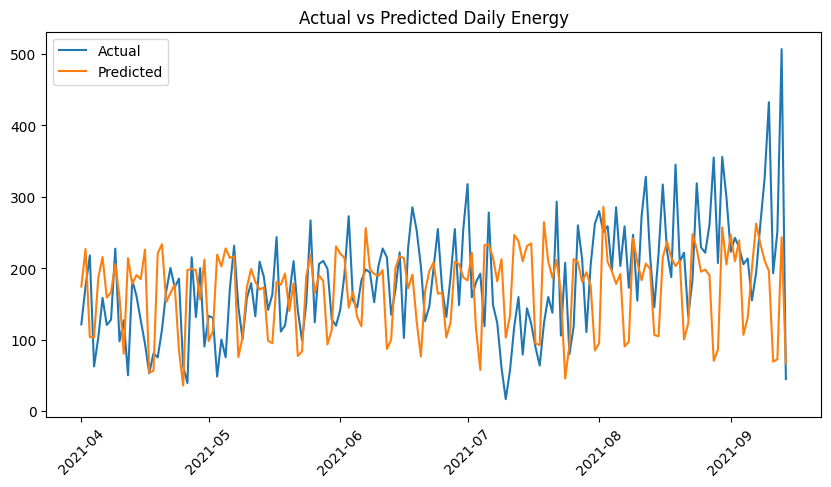

In [22]:
#Linear regression model
model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("Linear Regression MAE:", mae)
print("Linear Regression RMSE:", rmse)

plt.figure(figsize=(10, 5))
plt.plot(test["date"], y_test, label="Actual")
plt.plot(test["date"], preds, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Daily Energy")
plt.xticks(rotation=45)
plt.show()

Random Forest MAE: 86.9491777548832
Random Forest RMSE: 108.34054251016248


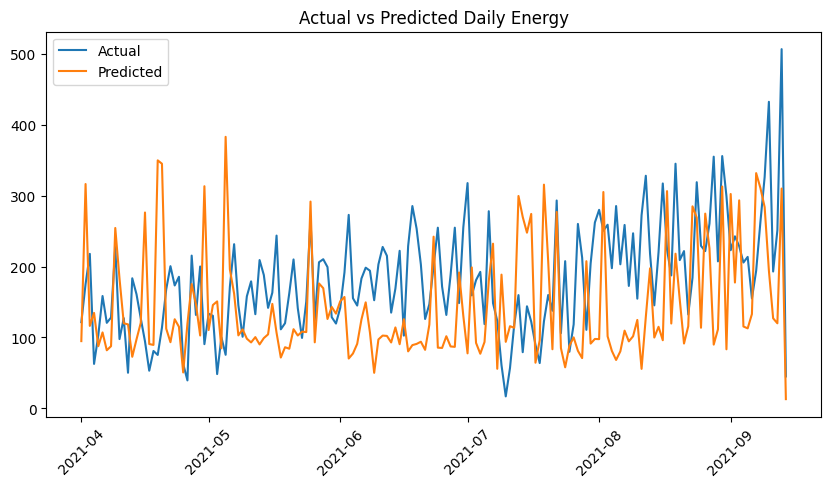

In [23]:
#random forest model
rfmodel = RandomForestRegressor(n_estimators=100, random_state=42)
rfmodel.fit(X_train, y_train)

rfpreds = rfmodel.predict(X_test)

mae = mean_absolute_error(y_test, rfpreds)
rmse = np.sqrt(mean_squared_error(y_test, rfpreds))

print("Random Forest MAE:", mae)
print("Random Forest RMSE:", rmse)

plt.figure(figsize=(10, 5))
plt.plot(test["date"], y_test, label="Actual")
plt.plot(test["date"], rfpreds, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Daily Energy")
plt.xticks(rotation=45)
plt.show()

XGBoost MAE: 86.6258517337823
XGboost RMSE: 106.02145301190438


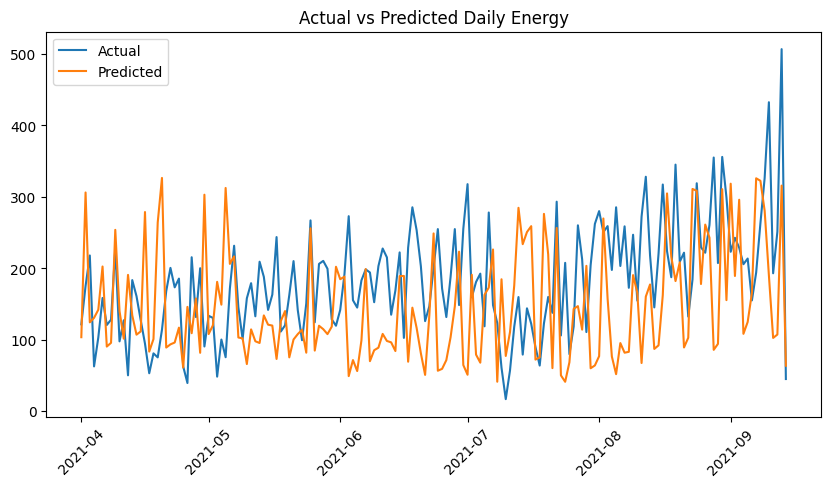

In [25]:
#xgboost model
xgmodel = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)
xgmodel.fit(X_train, y_train)

xgpreds = xgmodel.predict(X_test)

mae = mean_absolute_error(y_test, xgpreds)
rmse = np.sqrt(mean_squared_error(y_test, xgpreds))

print("XGBoost MAE:", mae)
print("XGboost RMSE:", rmse)

plt.figure(figsize=(10, 5))
plt.plot(test["date"], y_test, label="Actual")
plt.plot(test["date"], xgpreds, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Daily Energy")
plt.xticks(rotation=45)
plt.show()